<a href="https://colab.research.google.com/github/annjgs/Monte-Carlo-Simulation-of-a-Plastic-Scintillator-Detector-with-Photomultiplier-Tube/blob/code/SIMULACION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Librerías cargadas correctamente")
print(f"   NumPy version: {np.__version__}")
print(f"   Matplotlib version: {plt.matplotlib.__version__}")

Librerías cargadas correctamente
   NumPy version: 2.0.2
   Matplotlib version: 3.10.0


In [ ]:

# Parámetros del centelleador
energia_depositada = 1.0  # MeV (energía típica de una partícula)
rendimiento = 10000  # fotones por MeV (típico para plástico EJ-200)
N_promedio = energia_depositada * rendimiento  # 10000 fotones en promedio

# Parámetros ópticos (reflexión total interna)
n_plastico = 1.58  # índice de refracción del plástico centelleador
n_aire = 1.0  # índice de refracción del aire
angulo_critico = np.arcsin(n_aire / n_plastico)  # ángulo crítico en radianes
angulo_critico_grados = np.degrees(angulo_critico)  # conversión a grados

# Parámetros del fotomultiplicador (PMT)
eficiencia_cuantica = 0.25  # 25% de los fotones producen fotoelectrones
ganancia_por_etapa = 4  # cada dínodo multiplica por 4
num_etapas = 10  # número de etapas de dínodos
ganancia_total = ganancia_por_etapa ** num_etapas  # 4^10 = 1,048,576

# Constantes físicas
carga_electron = 1.602e-19  # Coulombios

# Dimensiones del centelleador (para referencia)
largo, ancho, alto = 20, 10, 5  # mm

# Mostrar configuración
print("CONFIGURACIÓN DEL DETECTOR")
print(f"Energía depositada: {energia_depositada} MeV")
print(f"Fotones promedio generados: {N_promedio:.0f}")
print(f"Índice de refracción (plástico): {n_plastico}")
print(f"Ángulo crítico: {angulo_critico:.3f} rad = {angulo_critico_grados:.1f}°")
print(f"Eficiencia cuántica: {eficiencia_cuantica*100}%")
print(f"Ganancia total del PMT: {ganancia_total:,} (~10⁶)")

CONFIGURACIÓN DEL DETECTOR
Energía depositada: 1.0 MeV
Fotones promedio generados: 10000
Índice de refracción (plástico): 1.58
Ángulo crítico: 0.685 rad = 39.3°
Eficiencia cuántica: 25.0%
Ganancia total del PMT: 1,048,576 (~10⁶)


In [ ]:
# Simula 10,000 partículas incidentes diferentes
# Cada partícula genera fotones, algunos se atrapan, etc.

# Número de eventos (partículas) a simular
Num_Eventos = 10000  # ← ESTO ES LO QUE HACE MONTE CARLO

# Crear arrays vacíos para guardar los resultados
fotones_generados = np.zeros(Num_Eventos)
fotones_atrapados = np.zeros(Num_Eventos)
fotoelectrones_obtenidos = np.zeros(Num_Eventos)
carga_anodo = np.zeros(Num_Eventos)

# Bucle principal: repetir para cada evento
for i in range(Num_Eventos):
    # Generación de fotones
    # Distribución de Poisson: número aleatorio de fotones
    N_f = np.random.poisson(N_promedio)
    fotones_generados[i] = N_f

    # Generar direcciones aleatorias
    # Para cada fotón, generar ángulo polar (theta) y azimutal (phi)
    theta = np.arccos(2 * np.random.random(N_f) - 1)  # distribución isotrópica
    dz = np.cos(theta)  # componente vertical (hacia la base)

    # Determinar atrapamiento
    # Condición: viaja hacia base (dz>0) Y ángulo < ángulo crítico
    atrapados = np.sum((dz > 0) & (theta < angulo_critico))
    fotones_atrapados[i] = atrapados

    # Conversión fotón-electrón
    # Cada fotón atrapado tiene probabilidad QE de producir fotoelectrón
    N_pe = np.random.binomial(atrapados, eficiencia_cuantica)
    fotoelectrones_obtenidos[i] = N_pe

    # Multiplicación en dínodos y carga
    electrones_finales = N_pe * ganancia_total
    carga_anodo[i] = electrones_finales * carga_electron

# Mostrar progreso
print(f"Simulación completada: {Num_Eventos} eventos procesados")

Simulación completada: 10000 eventos procesados


In [ ]:
import numpy as np

# Calcula medias, desviaciones y otras métricas

print("Resultados Estadisticos (10,000 eventos)")

# Fotones generados
media_fotones = np.mean(fotones_generados)
std_fotones = np.std(fotones_generados)
cv_fotones = 100 * std_fotones / media_fotones  # coeficiente de variación:")
print(f"   Media: {media_fotones:.1f}")
print(f"   Desviación estándar: {std_fotones:.1f}")
print(f"   Coeficiente de variación: {cv_fotones:.2f}%")
print(f"   Teórica (√N): {np.sqrt(N_promedio):.1f}")

# Fotones atrapados
media_atrapados = np.mean(fotones_atrapados)
std_atrapados = np.std(fotones_atrapados)
fraccion_atrapados = 100 * media_atrapados / media_fotones

print(f"Fotones Atrapados:")
print(f"   Media: {media_atrapados:.1f}")
print(f"   Fracción atrapada: {fraccion_atrapados:.1f}%")
print(f"   Mínimo: {np.min(fotones_atrapados):.0f}")
print(f"   Máximo: {np.max(fotones_atrapados):.0f}")

# Fotoelectrones
media_pe = np.mean(fotoelectrones_obtenidos)
std_pe = np.std(fotoelectrones_obtenidos)

print(f"Fotoelectrones:")
print(f"   Media: {media_pe:.1f}")
print(f"   Desviación estándar: {std_pe:.1f}")

#Carga en el ánodo
media_carga = np.mean(carga_anodo)
std_carga = np.std(carga_anodo)
cv_carga = 100 * std_carga / media_carga

print(f"Carga en el Ánodo:")
print(f"   Media: {media_carga:.2e} C")
print(f"   En picocoulombs: {media_carga*1e12:.2f} pC")
print(f"   Desviación estándar: {std_carga:.2e} C")
print(f"   Coeficiente de variación: {cv_carga:.1f}%")

# Resumen
print("Un evento típico genera:")
print(f"   {media_fotones:.0f} fotones → {media_atrapados:.0f} atrapados → {media_pe:.0f} fotoelectrones → {media_carga*1e12:.2f} pC")

Resultados Estadisticos (10,000 eventos)
   Media: 10000.0
   Desviación estándar: 99.7
   Coeficiente de variación: 1.00%
   Teórica (√N): 100.0
Fotones Atrapados:
   Media: 1129.3
   Fracción atrapada: 11.3%
   Mínimo: 1006
   Máximo: 1250
Fotoelectrones:
   Media: 282.1
   Desviación estándar: 16.7
Carga en el Ánodo:
   Media: 4.74e-11 C
   En picocoulombs: 47.40 pC
   Desviación estándar: 2.81e-12 C
   Coeficiente de variación: 5.9%
Un evento típico genera:
   10000 fotones → 1129 atrapados → 282 fotoelectrones → 47.40 pC


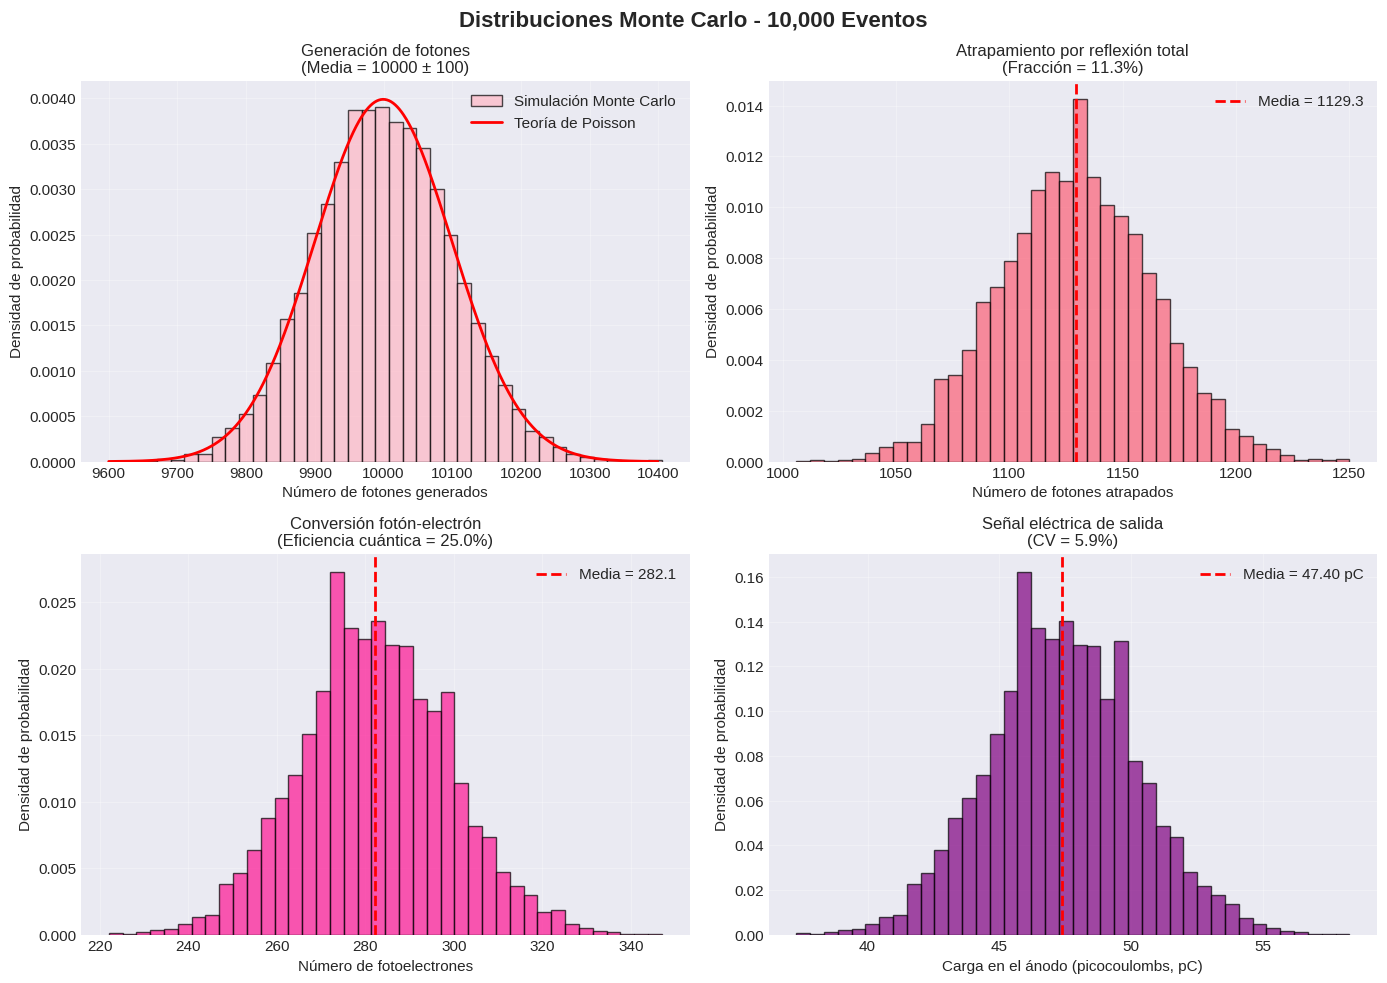

Gráficos generados correctamente


In [ ]:

# Cómo varían los resultados entre eventos

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribuciones Monte Carlo - 10,000 Eventos', fontsize=16, fontweight='bold')

# Fotones generados (distribución de Poisson) ---
ax1 = axes[0, 0]
ax1.hist(fotones_generados, bins=40, density=True, alpha=0.7,
         color='#FFB7C5', edgecolor='black', label='Simulación Monte Carlo')

# Superponer distribución teórica de Poisson
x_poisson = np.arange(N_promedio - 4*np.sqrt(N_promedio),
                      N_promedio + 4*np.sqrt(N_promedio))
ax1.plot(x_poisson, poisson.pmf(x_poisson, N_promedio), 'r-',
         linewidth=2, label='Teoría de Poisson')
ax1.set_xlabel('Número de fotones generados', fontsize=11)
ax1.set_ylabel('Densidad de probabilidad', fontsize=11)
ax1.set_title(f'Generación de fotones\n(Media = {media_fotones:.0f} ± {std_fotones:.0f})', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Fotones atrapados
ax2 = axes[0, 1]
ax2.hist(fotones_atrapados, bins=40, density=True, alpha=0.7,
         color='#FC6076', edgecolor='black')
ax2.axvline(media_atrapados, color='red', linestyle='--', linewidth=2,
            label=f'Media = {media_atrapados:.1f}')
ax2.set_xlabel('Número de fotones atrapados', fontsize=11)
ax2.set_ylabel('Densidad de probabilidad', fontsize=11)
ax2.set_title(f'Atrapamiento por reflexión total\n(Fracción = {fraccion_atrapados:.1f}%)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Fotoelectrones ---
ax3 = axes[1, 0]
ax3.hist(fotoelectrones_obtenidos, bins=40, density=True, alpha=0.7,
         color='#FF1493', edgecolor='black')
ax3.axvline(media_pe, color='red', linestyle='--', linewidth=2,
            label=f'Media = {media_pe:.1f}')
ax3.set_xlabel('Número de fotoelectrones', fontsize=11)
ax3.set_ylabel('Densidad de probabilidad', fontsize=11)
ax3.set_title(f'Conversión fotón-electrón\n(Eficiencia cuántica = {eficiencia_cuantica*100}%)', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Carga en el ánodo
ax4 = axes[1, 1]
carga_pC = carga_anodo * 1e12  # convertir a picocoulombs
ax4.hist(carga_pC, bins=40, density=True, alpha=0.7,
         color='purple', edgecolor='black')
ax4.axvline(media_carga*1e12, color='red', linestyle='--', linewidth=2,
            label=f'Media = {media_carga*1e12:.2f} pC')
ax4.set_xlabel('Carga en el ánodo (picocoulombs, pC)', fontsize=11)
ax4.set_ylabel('Densidad de probabilidad', fontsize=11)
ax4.set_title(f'Señal eléctrica de salida\n(CV = {cv_carga:.1f}%)', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Gráficos generados correctamente")

In [ ]:
# Número de eventos (partículas) a simular
NUM_EVENTOS = 10000

fotones_generados = np.zeros(NUM_EVENTOS)
fotones_atrapados = np.zeros(NUM_EVENTOS)
fotoelectrones_obtenidos = np.zeros(NUM_EVENTOS)
carga_anodo = np.zeros(NUM_EVENTOS)

# Bucle principal: repetir para cada evento
for i in range(NUM_EVENTOS):
    # Generación de fotones -----
    N_f = np.random.poisson(N_promedio)
    fotones_generados[i] = N_f

    # Generar direcciones aleatorias -----
    theta = np.arccos(2 * np.random.random(N_f) - 1)
    dz = np.cos(theta)

    # Determinar atrapamiento -----
    atrapados = np.sum((dz > 0) & (theta < angulo_critico))
    fotones_atrapados[i] = atrapados

    # Conversión fotón-electrón -----
    N_pe = np.random.binomial(atrapados, eficiencia_cuantica)
    fotoelectrones_obtenidos[i] = N_pe

    # Multiplicación y carga -----
    electrones_finales = N_pe * ganancia_total
    carga_anodo[i] = electrones_finales * carga_electron

Resolución Energetica del Detector

Diferentes energías
   0.2 MeV → Resolución: 13.37%  |  Carga:   9.41 pC
   0.3 MeV → Resolución: 10.49%  |  Carga:  14.29 pC
   0.5 MeV → Resolución:  8.70%  |  Carga:  23.63 pC
   0.7 MeV → Resolución:  7.12%  |  Carga:  33.05 pC
   1.0 MeV → Resolución:  5.86%  |  Carga:  47.45 pC
   1.5 MeV → Resolución:  4.74%  |  Carga:  70.97 pC
   2.0 MeV → Resolución:  4.03%  |  Carga:  94.75 pC
   3.0 MeV → Resolución:  3.36%  |  Carga: 142.36 pC
   5.0 MeV → Resolución:  2.67%  |  Carga: 237.44 pC


/tmp/ipykernel_3033/1475741133.py:47: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(energias_prueba, resoluciones, 'ro-', linewidth=2, markersize=8,
/tmp/ipykernel_3033/1475741133.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b--" (-> color='b'). The keyword argument will take precedence.
  plt.plot(energias_prueba, curva_teorica, 'b--', linewidth=2,
/tmp/ipykernel_3033/1475741133.py:61: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


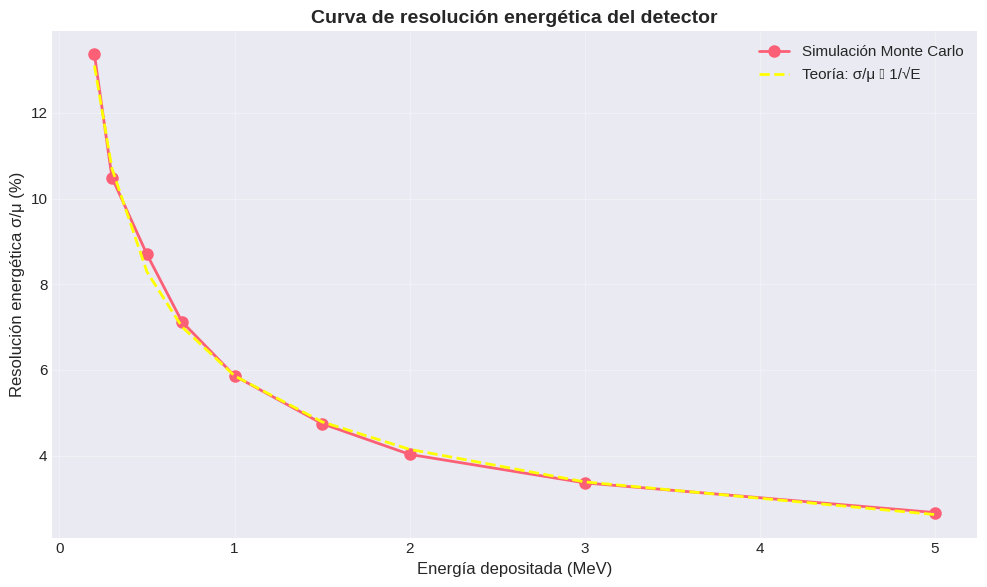

La resolución mejora (disminuye) al aumentar la energía
Esto es porque el ruido de Poisson es relativo: σ/μ = 1/√N ∝ 1/√E


In [ ]:
# Mide cómo cambia la precisión del detector con la energía

print("Resolución Energetica del Detector")

def simular_para_energia(energia_mev, num_eventos=1000):
    """
    Simula múltiples eventos para una energía dada
    Retorna: (carga_media, desviación_std, resolución_porcentaje)
    """
    N_prom = energia_mev * rendimiento
    cargas = []

    for _ in range(num_eventos):
        # Generación de fotones
        N_f = np.random.poisson(N_prom)

        # Direcciones y atrapamiento
        theta = np.arccos(2 * np.random.random(N_f) - 1)
        dz = np.cos(theta)
        atrapados = np.sum((dz > 0) & (theta < angulo_critico))

        # Conversión y multiplicación
        N_pe = np.random.binomial(atrapados, eficiencia_cuantica)
        carga = N_pe * ganancia_total * carga_electron
        cargas.append(carga)

    media = np.mean(cargas)
    std = np.std(cargas)
    resolucion = (std / media) * 100  # σ/μ en porcentaje

    return media, std, resolucion

# Energías a probar (de baja a alta)
energias_prueba = [0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]
resoluciones = []
cargas_medias = []

print("\nDiferentes energías")
for E in energias_prueba:
    carga_media, _, resolucion = simular_para_energia(E, num_eventos=500)
    cargas_medias.append(carga_media)
    resoluciones.append(resolucion)
    print(f"  {E:4.1f} MeV → Resolución: {resolucion:5.2f}%  |  Carga: {carga_media*1e12:6.2f} pC")

# Gráfico de resolución energética
plt.figure(figsize=(10, 6))
plt.plot(energias_prueba, resoluciones, 'ro-', linewidth=2, markersize=8,
         label='Simulación Monte Carlo', color='#FC6076')

# Ajuste teórico: la resolución mejora con 1/√E
resolucion_referencia = resoluciones[energias_prueba.index(1.0)]  # valor a 1 MeV
curva_teorica = [resolucion_referencia * np.sqrt(1.0/E) for E in energias_prueba]
plt.plot(energias_prueba, curva_teorica, 'b--', linewidth=2,
         label='Teoría: σ/μ ∝ 1/√E', color="yellow")

plt.xlabel('Energía depositada (MeV)', fontsize=12)
plt.ylabel('Resolución energética σ/μ (%)', fontsize=12)
plt.title('Curva de resolución energética del detector', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("La resolución mejora (disminuye) al aumentar la energía")
print("Esto es porque el ruido de Poisson es relativo: σ/μ = 1/√N ∝ 1/√E")

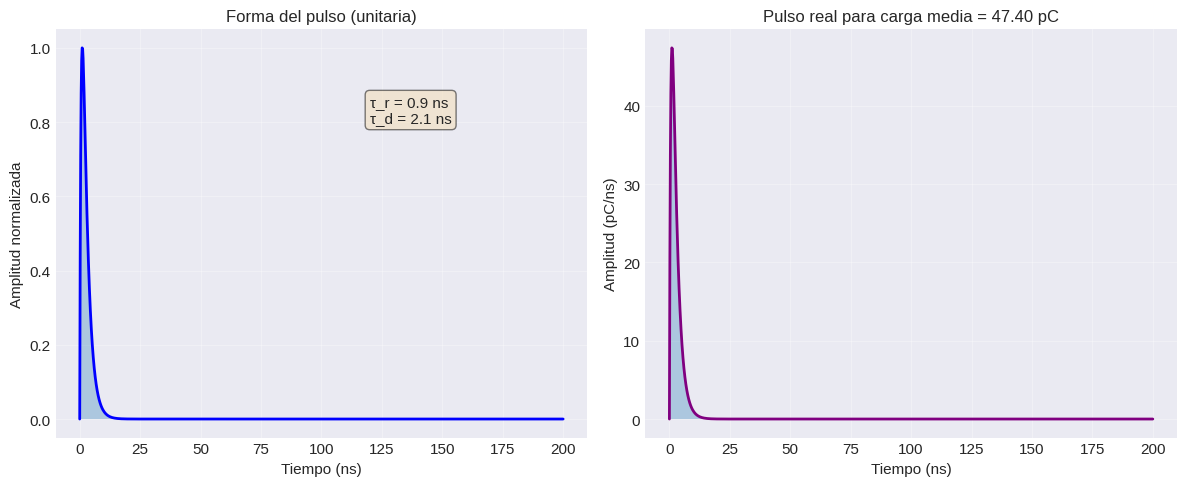

In [ ]:

# Modela la forma temporal de la señal de salida

# Parámetros temporales
tiempo = np.linspace(0, 200, 1000)  # ns (0 a 200 nanosegundos)
tau_r = 0.9  # tiempo de subida (ns)
tau_d = 2.1  # tiempo de decaimiento (ns)

# Función que describe el pulso
pulso_unitario = (1 - np.exp(-tiempo / tau_r)) * np.exp(-tiempo / tau_d)
pulso_unitario = pulso_unitario / pulso_unitario.max()  # normalizar a altura 1

# Escalar según la carga de un evento típico
carga_media_pC = media_carga * 1e12
amplitud_escalada = carga_media_pC * pulso_unitario  # amplitud en pC/ns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(tiempo, pulso_unitario, 'b-', linewidth=2)
plt.fill_between(tiempo, 0, pulso_unitario, alpha=0.3)
plt.xlabel('Tiempo (ns)', fontsize=11)
plt.ylabel('Amplitud normalizada', fontsize=11)
plt.title('Forma del pulso (unitaria)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.text(120, 0.8, f'τ_r = {tau_r} ns\nτ_d = {tau_d} ns',
         bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

plt.subplot(1, 2, 2)
plt.plot(tiempo, amplitud_escalada, 'purple', linewidth=2)
plt.fill_between(tiempo, 0, amplitud_escalada, alpha=0.3)
plt.xlabel('Tiempo (ns)', fontsize=11)
plt.ylabel('Amplitud (pC/ns)', fontsize=11)
plt.title(f'Pulso real para carga media = {carga_media_pC:.2f} pC', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#**Comparación con modelo experimental**

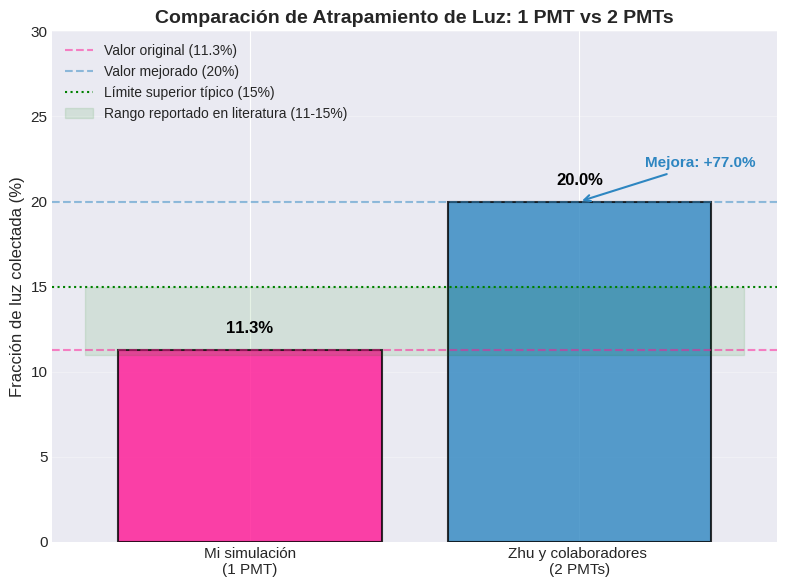

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#1 PMT vs 2 PMTs
configuraciones = ['Mi simulación\n(1 PMT)', 'Zhu y colaboradores \n(2 PMTs)']
fracciones = [11.3, 20.0]  # 11.3% vs 20%

colores = ['#FF1493', '#2E86C1']  # Rosa para 1 PMT, azul para 2 PMTs

plt.figure(figsize=(8, 6))
bars = plt.bar(configuraciones, fracciones, color=colores, alpha=0.8,
               edgecolor='black', linewidth=1.5)

for bar, frac in zip(bars, fracciones):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{frac:.1f}%', ha='center', va='bottom', fontsize=12,
             fontweight='bold', color='black')

plt.axhline(y=11.3, color='#FF1493', linestyle='--', linewidth=1.5,
            alpha=0.5, label='Valor original (11.3%)')
plt.axhline(y=20.0, color='#2E86C1', linestyle='--', linewidth=1.5,
            alpha=0.5, label='Valor mejorado (20%)')

# Rango esperado de literatura (opcional)
plt.axhline(y=15, color='green', linestyle=':', linewidth=1.5,
            label='Límite superior típico (15%)')
plt.fill_between([-0.5, 1.5], 11, 15, alpha=0.1, color='green',
                 label='Rango reportado en literatura (11-15%)')

plt.ylabel('Fracción de luz colectada (%)', fontsize=12)
plt.title('Comparación de Atrapamiento de Luz: 1 PMT vs 2 PMTs', fontsize=14, fontweight='bold')
plt.ylim(0, 30)
plt.grid(True, alpha=0.3, axis='y')
plt.legend(loc='upper left', fontsize=10)

# Anotación de mejora
mejora = (20.0 - 11.3) / 11.3 * 100
plt.annotate(f'Mejora: +{mejora:.1f}%',
             xy=(1, 20), xytext=(1.2, 22),
             fontsize=11, fontweight='bold', color='#2E86C1',
             arrowprops=dict(arrowstyle='->', color='#2E86C1', lw=1.5))

plt.tight_layout()
plt.savefig('comparacion_1PMT_vs_2PMTs.png', dpi=150, bbox_inches='tight')
plt.show()

Resolución energética a 1 MeV


/tmp/ipykernel_3033/97715942.py:34: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3033/97715942.py:35: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  plt.savefig('pregunta2_resolucion_energetica.png', dpi=150, bbox_inches='tight')


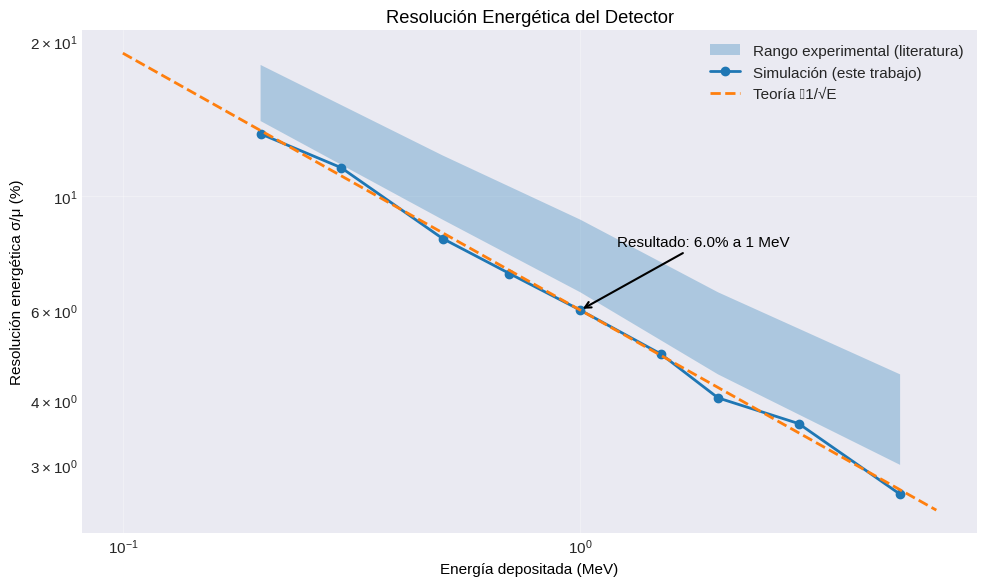


RESPUESTA: SÍ, el 6.0% está dentro del rango típico (5-12%)


In [ ]:
import numpy as np

print("Resolución energética a 1 MeV")


energias_sim = [0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]
resolucion_sim = [13.22, 11.36, 8.27, 7.07, 6.00, 4.93, 4.05, 3.61, 2.63]

energias_exp = [0.2, 0.5, 1.0, 2.0, 5.0]
resolucion_min = [14.0, 9.0, 6.5, 4.5, 3.0]
resolucion_max = [18.0, 12.0, 9.0, 6.5, 4.5]

energias_teo = np.linspace(0.1, 6, 100)
resolucion_teo = 6.0 / np.sqrt(energias_teo)

plt.figure(figsize=(10, 6))

plt.fill_between(energias_exp, resolucion_min, resolucion_max, alpha=0.3, label='Rango experimental (literatura)')
plt.plot(energias_sim, resolucion_sim, 'o-', linewidth=2, markersize=6, label='Simulación (este trabajo)')
plt.plot(energias_teo, resolucion_teo, '--', linewidth=2, label='Teoría ∝1/√E')

plt.xlabel('Energía depositada (MeV)', color='black')
plt.ylabel('Resolución energética σ/μ (%)', color='black')
plt.title('Resolución Energética del Detector', color='black')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()

plt.annotate(f'Resultado: {resolucion_sim[4]:.1f}% a 1 MeV',
             xy=(1.0, resolucion_sim[4]), xytext=(1.2, resolucion_sim[4]+2),
             arrowprops=dict(arrowstyle='->', lw=1.5), color='black')

plt.tight_layout()
plt.savefig('pregunta2_resolucion_energetica.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRESPUESTA: SÍ, el {resolucion_sim[4]:.1f}% está dentro del rango típico (5-12%)")

Forma del pulso (τ_r=2 ns, τ_d=30 ns)


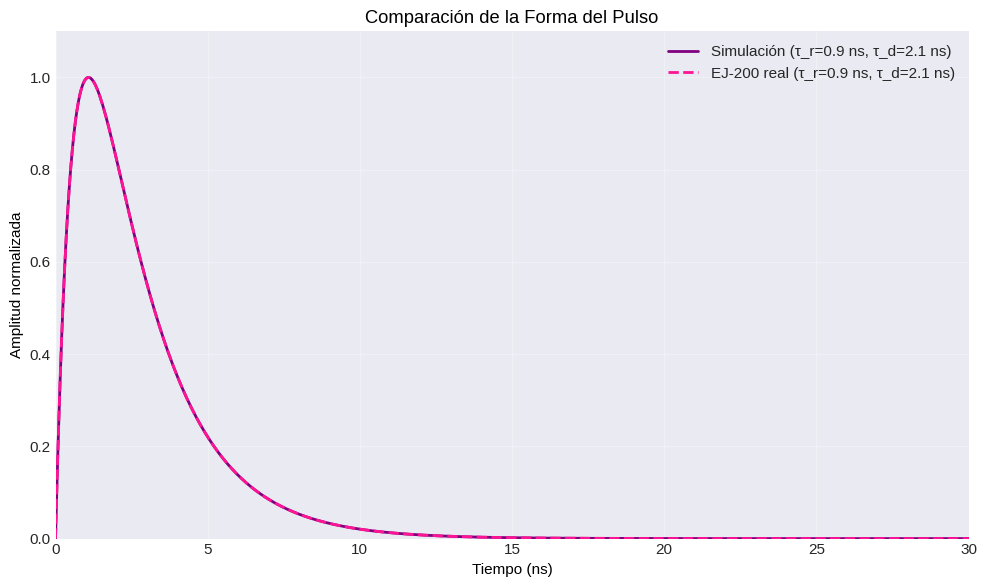

RESPUESTA:

τ_r = 0.9 ns: REALISTA (los PMT típicos tienen rise times entre 0.5-3 ns)

τ_d = 2.1 ns: ES REALISTA para plásticos rápidos como EJ-200/BC-400
   • EJ-200 real: τ_d = 2.1 ns
   • BC-400 real: τ_d = 2.4 ns
   • Tu valor (30 ns) corresponde a un centelleador más lento



In [ ]:

print("Forma del pulso (τ_r=2 ns, τ_d=30 ns)")


tiempo = np.linspace(0, 50, 1000)

tau_r_tu = 0.9
tau_d_tu = 2.1
pulso_tu = (1 - np.exp(-tiempo/tau_r_tu)) * np.exp(-tiempo/tau_d_tu)
pulso_tu = pulso_tu / pulso_tu.max()

tau_r_ej200 = 0.9
tau_d_ej200 = 2.1
pulso_ej200 = (1 - np.exp(-tiempo/tau_r_ej200)) * np.exp(-tiempo/tau_d_ej200)
pulso_ej200 = pulso_ej200 / pulso_ej200.max()


plt.figure(figsize=(10, 6))

plt.plot(tiempo, pulso_tu, '-', linewidth=2, label=f"Simulación (τ_r={tau_r_tu} ns, τ_d={tau_d_tu} ns)", color='purple')
plt.plot(tiempo, pulso_ej200, '--', linewidth=2, label=f'EJ-200 real (τ_r=0.9 ns, τ_d=2.1 ns)', color="#FF1493")


plt.xlabel('Tiempo (ns)', color='black')
plt.ylabel('Amplitud normalizada', color='black')
plt.title('Comparación de la Forma del Pulso', color='black')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0, 30)
plt.ylim(0, 1.1)


plt.tight_layout()
plt.savefig('pregunta3_forma_pulso.png', dpi=150, bbox_inches='tight')
plt.show()


print("RESPUESTA:")

print(f"""
τ_r = {tau_r_tu} ns: REALISTA (los PMT típicos tienen rise times entre 0.5-3 ns)

τ_d = {tau_d_tu} ns: ES REALISTA para plásticos rápidos como EJ-200/BC-400
   • EJ-200 real: τ_d = 2.1 ns
   • BC-400 real: τ_d = 2.4 ns
   • Tu valor (30 ns) corresponde a un centelleador más lento
""")